# Cells

1. LIDC scatter (Fig 7a)
2. Chaksu scatter (Fig 7b)
3. Perf. subtable (Table 2a)
4. Ent. subtable (Table 2b)
5. Task aggr. scatter (Fig 12)
6. Dataset aggr. scatter (Fig 13)
7. GED vs AU scatter (Fig 15)

# LIDC scatter (Fig 7a)

In [ ]:
/home/jloch/Desktop/diff/luzern/values/saves/origlidc128/test_results/ssn_ensemble_2/e1000_ema

Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4


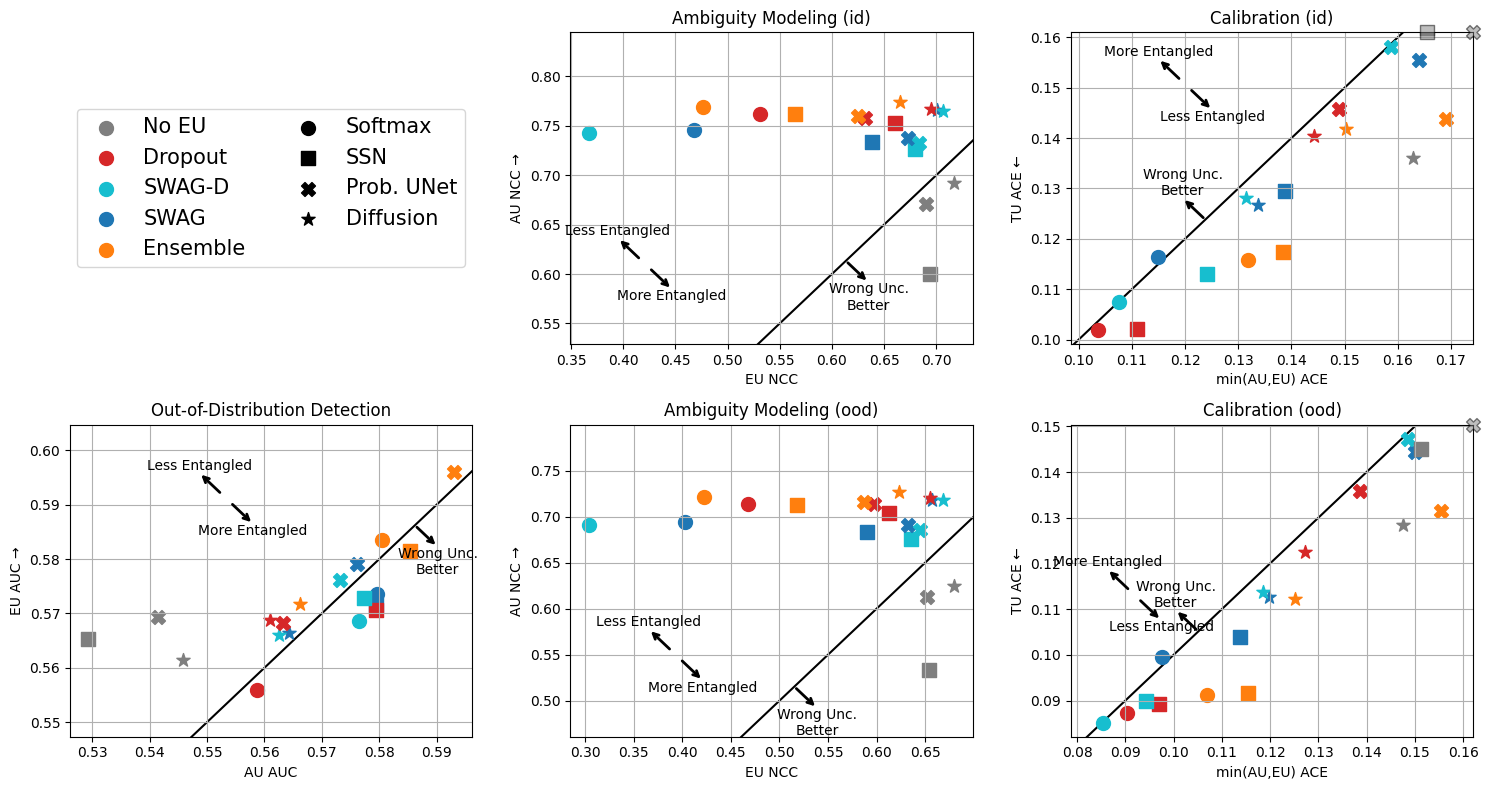

In [127]:
from helpers import model_scatter, plot_scatter_grid
# chaksu
from helpers import load_result_table,plot_metric_matrix, plot_mm_grid
table = load_result_table(formatter="{AU}_{EU}_{seed}",
                          epochs=[500,1000],
                           loop_params = {
                            "AU": ["softmax", "ssn", "diffusion", "prob_unet2"],
                            "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/origlidc128/test_results/",
                aggregation_type = "border_normalized",#"border_normalized", "patch_level"
                mean_seeded_table = "01234",
                add_avg_ood = True,
                ace_type = "gace",
                add_rank=True)
plot_scatter_grid(table=table, mini_tables=None, override={"mini_alpha": 0},
                 save_path="/home/jloch/Desktop/diff/writing/ECCV2026/ECCV_2026_AU_EU/images2/scatter_grid_lidc.pdf");

# Chaksu scatter (Fig 7b)

Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4


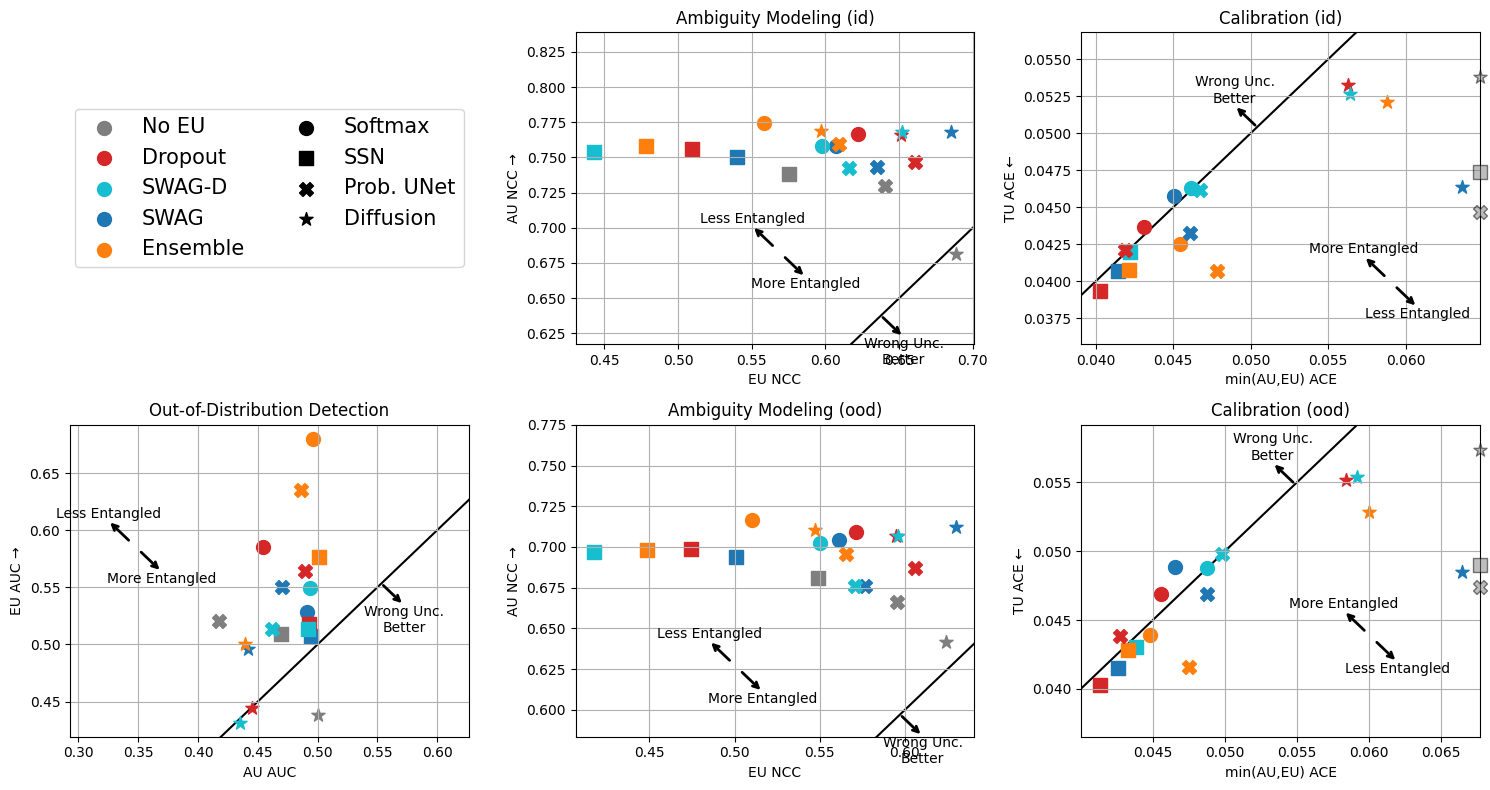

In [118]:
from helpers import model_scatter, plot_scatter_grid
# chaksu
from helpers import load_result_table,plot_metric_matrix, plot_mm_grid
table = load_result_table(formatter="{AU}_{EU}_{seed}",
                          epochs=[500],
                           loop_params = {
                            "AU": ["softmax", "ssn", "diffusion", "prob_unet"],
                            "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/chaksu128/test_results/",
                aggregation_type = "border_normalized",#"border_normalized", "patch_level"
                mean_seeded_table = "01234",
                ace_type="ace",
                add_avg_ood = True,
                add_rank=True)
plot_scatter_grid(table=table, mini_tables=None, override={"mini_alpha": 0},
                 save_path="/home/jloch/Desktop/diff/writing/ECCV2026/ECCV_2026_AU_EU/images2/scatter_grid_chaksu.pdf");

# Perf. subtable (Table 2a)

In [119]:
import numpy as np
def formatter(mean,std):
    n = 5
    t_val_5p_975 = 2.776 #t value for 4 degrees of freedom (5 seeds - 1) and 95% confidence
    if np.isnan(mean):
        return r"\multicolumn{1}{c}{N/A}"
    nice_mean = f"{np.round(mean,1):.1f}"
    if std is None or np.isnan(std):
        return nice_mean
    else:
        nice_std = f"{np.round(std/np.sqrt(n)*t_val_5p_975,1):.1f}"
        return f"{nice_mean}±{nice_std}"

is_ent = False
amb_cal_2 = False
# lidc
import numpy as np
from helpers import load_result_table,plot_metric_matrix, plot_mm_grid, pretty_pivot
table = load_result_table(formatter="{AU}_{EU}_{seed}",epochs=[500,1000],
                           loop_params = {
                            "AU": ["softmax", "ssn", "diffusion", "prob_unet2"],
                            "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/origlidc128/test_results/",
                aggregation_type = "border_normalized",#"border_normalized", "patch_level"
                add_avg_ood = True,
                amb_cal_2 = amb_cal_2,
                ace_type="gace",
                add_rank=True,
                mean_seeded_table="01234")
std_table = load_result_table(formatter="{AU}_{EU}_{seed}",epochs=[500,1000],
                           loop_params = {
                            "AU": ["softmax", "ssn", "diffusion", "prob_unet2"],
                            "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/origlidc128/test_results/",
                aggregation_type = "border_normalized",#"border_normalized", "patch_level"
                add_avg_ood = True,
                amb_cal_2 = amb_cal_2,
                ace_type="gace",
                add_rank=True,
                std_seeded_table="01234")


key = "ENTRANK_avg" if is_ent else "PERFRANK_avg"

lidc_rank_table = pretty_pivot(table, key=key)
lidc_rank_table_std = pretty_pivot(std_table, key=key)

for i in lidc_rank_table.index:
    for j in lidc_rank_table.columns:
        mean = lidc_rank_table.loc[i,j]
        std = lidc_rank_table_std.loc[i,j]
        lidc_rank_table.loc[i,j] = formatter(mean,std)

# chaksu
from helpers import load_result_table,plot_metric_matrix, plot_mm_grid, pretty_pivot
table = load_result_table(formatter="{AU}_{EU}_{seed}",epochs=[500],
                           loop_params = {
                            "AU": ["softmax", "ssn", "diffusion", "prob_unet"],
                            "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/chaksu128/test_results/",
                aggregation_type = "border_normalized",
                add_avg_ood = True,
                ace_type="ace",
                amb_cal_2 = amb_cal_2,
                add_rank=True,
                mean_seeded_table="01234")
std_table = load_result_table(formatter="{AU}_{EU}_{seed}",epochs=[500],
                           loop_params = {
                            "AU": ["softmax", "ssn", "diffusion", "prob_unet"],
                            "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/chaksu128/test_results/",
                aggregation_type = "border_normalized",
                add_avg_ood = True,
                amb_cal_2 = amb_cal_2,
                ace_type="ace",
                add_rank=True,
                std_seeded_table="01234")


key = "ENTRANK_avg" if is_ent else "PERFRANK_avg"

chaksu_rank_table = pretty_pivot(table, key=key)
chaksu_rank_table_std = pretty_pivot(std_table, key=key)

for i in chaksu_rank_table.index:
    for j in chaksu_rank_table.columns:
        mean = chaksu_rank_table.loc[i,j]
        std = chaksu_rank_table_std.loc[i,j]
        chaksu_rank_table.loc[i,j] = formatter(mean,std)

s = r"""
\begin{subtable}{\textwidth}
\centering
\setlength{\tabcolsep}{2pt}
\resizebox{\textwidth}{!}{%
\begin{tabular}{ll rrrr p{8pt} rrrr}
    \multicolumn{2}{c}{\textbf{[TYPE] Rank}} & \multicolumn{9}{c}{\textbf{AU Method}} \\
    \cmidrule(lr){3-11}
    & & \multicolumn{1}{c}{\textbf{\shortstack{Soft-\\max}}}
      & \multicolumn{1}{c}{\textbf{SSN}}
      & \multicolumn{1}{c}{\textbf{\shortstack{Prob.\\UNet}}}
      & \multicolumn{1}{c}{\textbf{Diff.}}
      & 
      & \multicolumn{1}{c}{\textbf{\shortstack{Soft-\\max}}}
      & \multicolumn{1}{c}{\textbf{SSN}}
      & \multicolumn{1}{c}{\textbf{\shortstack{Prob.\\UNet}}}
      & \multicolumn{1}{c}{\textbf{Diff.}} \\
    \midrule

    \multirow{5}{*}{\shortstack{\textbf{EU}\\\textbf{Method}}}
    & \textbf{No EU}    & XXX & XXX & XXX & XXX &   & XXX & XXX & XXX & XXX \\
    & \textbf{Dropout}  & XXX & XXX & XXX & XXX &   & XXX & XXX & XXX & XXX \\
    & \textbf{SWAG-D}   & XXX & XXX & XXX & XXX &   & XXX & XXX & XXX & XXX \\
    & \textbf{SWAG}     & XXX & XXX & XXX & XXX &   & XXX & XXX & XXX & XXX \\
    & \textbf{Ensemble} & XXX & XXX & XXX & XXX &   & XXX & XXX & XXX & XXX \\

    \midrule
    \\[-1.5em]
    \cmidrule(lr){3-6}\cmidrule(lr){8-11}
    \cmidrule(lr){3-6}\cmidrule(lr){8-11}

    % Dataset labels BELOW, with rules that stop exactly under their columns, skipping the ghost column.
    & & \multicolumn{4}{c}{\textbf{LIDC}} & & \multicolumn{4}{c}{\textbf{Chaksu}} \\
\end{tabular}
}
\caption{[CAPTION]}
\label{tab:[LABEL]_ranking}
\end{subtable}"""

if not is_ent:
    s = s.replace("[TYPE]", "Perf.")
    s = s.replace("[LABEL]", "performance")
    s = s.replace("[CAPTION]", "Ranking of the model performance (EU AUC, AU NCC, TU ACE).")
else:
    s = s.replace("[TYPE]", "Ent. ($\Delta$)")
    s = s.replace("[LABEL]", "entanglement")
    s = s.replace("[CAPTION]", "Ranking of the entanglement metric ($\Delta$).")

def render_entrank_table(lidc,chaksu):
    EU_order = ["No EU", "Dropout", "SWAG-D", "SWAG", "Ensemble"]
    assert list(lidc.index) == EU_order, f"Expected LIDC index to be {EU_order}, but got {list(lidc.index)}"
    assert list(chaksu.index) == EU_order, f"Expected Chaksu index to be {EU_order}, but got {list(chaksu.index)}"
    AU_order = ["Softmax", "SSN", "Prob. UNet", "Diffusion"]
    assert list(lidc.columns) == AU_order, f"Expected LIDC columns to be {AU_order}, but got {list(lidc.columns)}"
    assert list(chaksu.columns) == AU_order, f"Expected Chaksu columns to be {AU_order}, but got {list(chaksu.columns)}"
    s_out = s
    r = 0
    for row in s.split("\n"):
        if "XXX" in row:
            EU = EU_order[r]
            for AU in AU_order:
                xxx = lidc.loc[EU,AU] if isinstance(lidc.loc[EU,AU],str) else f"{lidc.loc[EU,AU]:.1f}"
                s_out = s_out.replace("XXX", xxx, 1)
            for AU in AU_order:
                xxx = chaksu.loc[EU,AU] if isinstance(chaksu.loc[EU,AU],str) else f"{chaksu.loc[EU,AU]:.1f}"
                s_out = s_out.replace("XXX", xxx, 1)
            r += 1
    s_out = s_out.replace("& nan±nan", "& N/A")
    s_out = s_out.replace("& nan", "& N/A")
    return s_out
print(render_entrank_table(lidc_rank_table,chaksu_rank_table))

Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4
Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4
Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4
Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4

\begin{subtable}{\textwidth}
\centering
\setlength{\tabcolsep}{2pt}
\resizebox{\textwidth}{!}{%
\begin{tabular}{ll rrrr p{8pt} rrrr}
    \multicolumn{2}{c}{\textbf{Perf. Rank}} & 

# Ent. subtable (Table 2b)

In [120]:
import numpy as np
def formatter(mean,std):
    n = 5
    t_val_5p_975 = 2.776 #t value for 4 degrees of freedom (5 seeds - 1) and 95% confidence
    if np.isnan(mean):
        return r"\multicolumn{1}{c}{N/A}"
    nice_mean = f"{np.round(mean,1):.1f}"
    if std is None or np.isnan(std):
        return nice_mean
    else:
        nice_std = f"{np.round(std/np.sqrt(n)*t_val_5p_975,1):.1f}"
        return f"{nice_mean}±{nice_std}"

is_ent = True
amb_cal_2 = False

# lidc
import numpy as np
from helpers import load_result_table,plot_metric_matrix, plot_mm_grid, pretty_pivot
table = load_result_table(formatter="{AU}_{EU}_{seed}",epochs=[500,1000],
                           loop_params = {
                            "AU": ["softmax", "ssn", "diffusion", "prob_unet2"],
                            "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/origlidc128/test_results/",
                aggregation_type = "border_normalized",#"border_normalized", "patch_level"
                add_avg_ood = True,
                ace_type="gace",
                amb_cal_2 = amb_cal_2,
                add_rank=True,
                mean_seeded_table="01234")
std_table = load_result_table(formatter="{AU}_{EU}_{seed}",epochs=[500,1000],
                           loop_params = {
                            "AU": ["softmax", "ssn", "diffusion", "prob_unet2"],
                            "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/origlidc128/test_results/",
                aggregation_type = "border_normalized",#"border_normalized", "patch_level"
                add_avg_ood = True,
                ace_type="gace",
                amb_cal_2 = amb_cal_2,
                add_rank=True,
                std_seeded_table="01234")


key = "ENTRANK_avg" if is_ent else "PERFRANK_avg"

lidc_rank_table = pretty_pivot(table, key=key)
lidc_rank_table_std = pretty_pivot(std_table, key=key)

for i in lidc_rank_table.index:
    for j in lidc_rank_table.columns:
        mean = lidc_rank_table.loc[i,j]
        std = lidc_rank_table_std.loc[i,j]
        lidc_rank_table.loc[i,j] = formatter(mean,std)

# chaksu
from helpers import load_result_table,plot_metric_matrix, plot_mm_grid, pretty_pivot
table = load_result_table(formatter="{AU}_{EU}_{seed}",epochs=[500],
                           loop_params = {
                            "AU": ["softmax", "ssn", "diffusion", "prob_unet"],
                            "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/chaksu128/test_results/",
                aggregation_type = "border_normalized",
                add_avg_ood = True,
                amb_cal_2= amb_cal_2,
                ace_type="ace",
                add_rank=True,
                mean_seeded_table="01234")
std_table = load_result_table(formatter="{AU}_{EU}_{seed}",epochs=[500],
                           loop_params = {
                            "AU": ["softmax", "ssn", "diffusion", "prob_unet"],
                            "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/chaksu128/test_results/",
                aggregation_type = "border_normalized",
                add_avg_ood = True,
                amb_cal_2 = amb_cal_2,
                ace_type="ace",
                add_rank=True,
                std_seeded_table="01234")


key = "ENTRANK_avg" if is_ent else "PERFRANK_avg"

chaksu_rank_table = pretty_pivot(table, key=key)
chaksu_rank_table_std = pretty_pivot(std_table, key=key)

for i in chaksu_rank_table.index:
    for j in chaksu_rank_table.columns:
        mean = chaksu_rank_table.loc[i,j]
        std = chaksu_rank_table_std.loc[i,j]
        chaksu_rank_table.loc[i,j] = formatter(mean,std)

s = r"""
\begin{subtable}{\textwidth}
\centering
\setlength{\tabcolsep}{2pt}
\resizebox{\textwidth}{!}{%
\begin{tabular}{ll rrrr p{8pt} rrrr}
    \multicolumn{2}{c}{\textbf{[TYPE] Rank}} & \multicolumn{9}{c}{\textbf{AU Method}} \\
    \cmidrule(lr){3-11}
    & & \multicolumn{1}{c}{\textbf{\shortstack{Soft-\\max}}}
      & \multicolumn{1}{c}{\textbf{SSN}}
      & \multicolumn{1}{c}{\textbf{\shortstack{Prob.\\UNet}}}
      & \multicolumn{1}{c}{\textbf{Diff.}}
      & 
      & \multicolumn{1}{c}{\textbf{\shortstack{Soft-\\max}}}
      & \multicolumn{1}{c}{\textbf{SSN}}
      & \multicolumn{1}{c}{\textbf{\shortstack{Prob.\\UNet}}}
      & \multicolumn{1}{c}{\textbf{Diff.}} \\
    \midrule

    \multirow{5}{*}{\shortstack{\textbf{EU}\\\textbf{Method}}}
    & \textbf{No EU}    & XXX & XXX & XXX & XXX &   & XXX & XXX & XXX & XXX \\
    & \textbf{Dropout}  & XXX & XXX & XXX & XXX &   & XXX & XXX & XXX & XXX \\
    & \textbf{SWAG-D}   & XXX & XXX & XXX & XXX &   & XXX & XXX & XXX & XXX \\
    & \textbf{SWAG}     & XXX & XXX & XXX & XXX &   & XXX & XXX & XXX & XXX \\
    & \textbf{Ensemble} & XXX & XXX & XXX & XXX &   & XXX & XXX & XXX & XXX \\

    \midrule
    \\[-1.5em]
    \cmidrule(lr){3-6}\cmidrule(lr){8-11}
    \cmidrule(lr){3-6}\cmidrule(lr){8-11}

    % Dataset labels BELOW, with rules that stop exactly under their columns, skipping the ghost column.
    & & \multicolumn{4}{c}{\textbf{LIDC}} & & \multicolumn{4}{c}{\textbf{Chaksu}} \\
\end{tabular}
}
\caption{[CAPTION]}
\label{tab:[LABEL]_ranking}
\end{subtable}"""

if not is_ent:
    s = s.replace("[TYPE]", "Perf.")
    s = s.replace("[LABEL]", "performance")
    s = s.replace("[CAPTION]", "Ranking of the model performance (EU AUC, AU NCC, TU ACE).")
else:
    s = s.replace("[TYPE]", "Ent. ($\Delta$)")
    s = s.replace("[LABEL]", "entanglement")
    s = s.replace("[CAPTION]", "Ranking of the entanglement metric ($\Delta$).")

def render_entrank_table(lidc,chaksu):
    EU_order = ["No EU", "Dropout", "SWAG-D", "SWAG", "Ensemble"]
    assert list(lidc.index) == EU_order, f"Expected LIDC index to be {EU_order}, but got {list(lidc.index)}"
    assert list(chaksu.index) == EU_order, f"Expected Chaksu index to be {EU_order}, but got {list(chaksu.index)}"
    AU_order = ["Softmax", "SSN", "Prob. UNet", "Diffusion"]
    assert list(lidc.columns) == AU_order, f"Expected LIDC columns to be {AU_order}, but got {list(lidc.columns)}"
    assert list(chaksu.columns) == AU_order, f"Expected Chaksu columns to be {AU_order}, but got {list(chaksu.columns)}"
    s_out = s
    r = 0
    for row in s.split("\n"):
        if "XXX" in row:
            EU = EU_order[r]
            for AU in AU_order:
                xxx = lidc.loc[EU,AU] if isinstance(lidc.loc[EU,AU],str) else f"{lidc.loc[EU,AU]:.1f}"
                s_out = s_out.replace("XXX", xxx, 1)
            for AU in AU_order:
                xxx = chaksu.loc[EU,AU] if isinstance(chaksu.loc[EU,AU],str) else f"{chaksu.loc[EU,AU]:.1f}"
                s_out = s_out.replace("XXX", xxx, 1)
            r += 1
    s_out = s_out.replace("& nan±nan", "& N/A")
    s_out = s_out.replace("& nan", "& N/A")
    return s_out
print(render_entrank_table(lidc_rank_table,chaksu_rank_table))

Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4
Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4
Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4
Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4

\begin{subtable}{\textwidth}
\centering
\setlength{\tabcolsep}{2pt}
\resizebox{\textwidth}{!}{%
\begin{tabular}{ll rrrr p{8pt} rrrr}
    \multicolumn{2}{c}{\textbf{Ent. ($\Delta$)

# Task aggr. scatter (Fig 12)

Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4
Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4


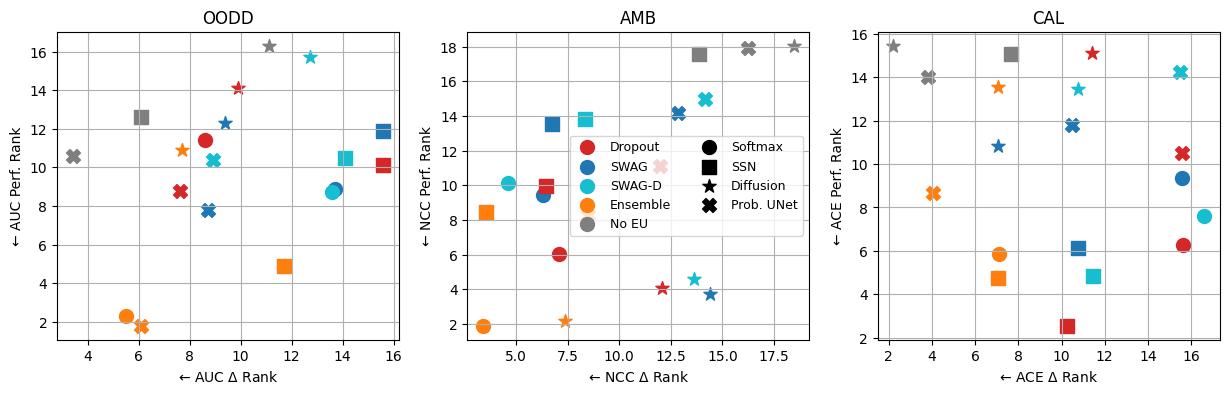

In [128]:
from helpers import load_result_table,model_scatter
import matplotlib.pyplot as plt
table_lidc = load_result_table(formatter="{AU}_{EU}_{seed}",epochs=[1000,500],
                           loop_params = {
                            "AU": ["softmax", "ssn", "diffusion", "prob_unet2"],
                            "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/origlidc128/test_results/",
                aggregation_type = "border_normalized",#"border_normalized", "patch_level"
                add_avg_ood = True,
                ace_type="gace",
                add_rank=True,
                mean_seeded_table="01234")
table_chaksu = load_result_table(formatter="{AU}_{EU}_{seed}",epochs=[500],
                        loop_params = {
                        "AU": ["softmax", "ssn", "diffusion", "prob_unet"],
                        "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
            },
            save_path = "/home/jloch/Desktop/diff/luzern/values/saves/chaksu128/test_results/",
            aggregation_type = "border_normalized",#"border_normalized", "patch_level"
            add_avg_ood = True,
            add_rank=True,
            ace_type="ace",
            mean_seeded_table="01234")
required_cols = ["AU","EU","ENTRANK_auc","PERFRANK_auc","ENTRANK_ncc","PERFRANK_ncc","ENTRANK_ace","PERFRANK_ace"]

#new table with only required cols, and (chaksu+lidc)/2 for all keys except AU and EU
table = table_lidc[required_cols].copy()
for col in required_cols:
    if col not in ["AU","EU"]:
        table[col] = (table_lidc[col] + table_chaksu[col]) / 2

fig, axs = plt.subplots(1,3, figsize=(15,4))

kwargs = {"x": "ENTRANK_auc", "y": "PERFRANK_auc", "xlabel": "← AUC $\Delta$ Rank", "ylabel": "← AUC Perf. Rank", 
         "equal_scaling": False, "plot_legend": False, "entangle_is_up": None,
         "add_xy": False, "title": "OODD"}
model_scatter(table=table, ax=axs[0],**kwargs);
kwargs = {"x": "ENTRANK_ncc", "y": "PERFRANK_ncc", "xlabel": "← NCC $\Delta$ Rank", "ylabel": "← NCC Perf. Rank", 
         "equal_scaling": False, "plot_legend": True, "entangle_is_up": None,
         "add_xy": False, "title": "AMB"}
#fig, ax = plt.subplots(figsize=(15,10))
model_scatter(table=table, ax=axs[1], **kwargs);
kwargs = {"x": "ENTRANK_ace", "y": "PERFRANK_ace", "xlabel": "← ACE $\Delta$ Rank", "ylabel": "← ACE Perf. Rank", 
         "equal_scaling": False, "plot_legend": False, "entangle_is_up": None,
         "add_xy": False, "title": "CAL"}
#fig, ax = plt.subplots(figsize=(15,10))
model_scatter(table=table, ax=axs[2], **kwargs);

save_path = "/home/jloch/Desktop/diff/writing/ECCV2026/ECCV_2026_AU_EU/images2/scatter_rank_task.pdf"
#save_path = None
if save_path is not None:
    plt.savefig(save_path, bbox_inches="tight")

# Dataset aggr. scatter (Fig 13)

Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4
Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4


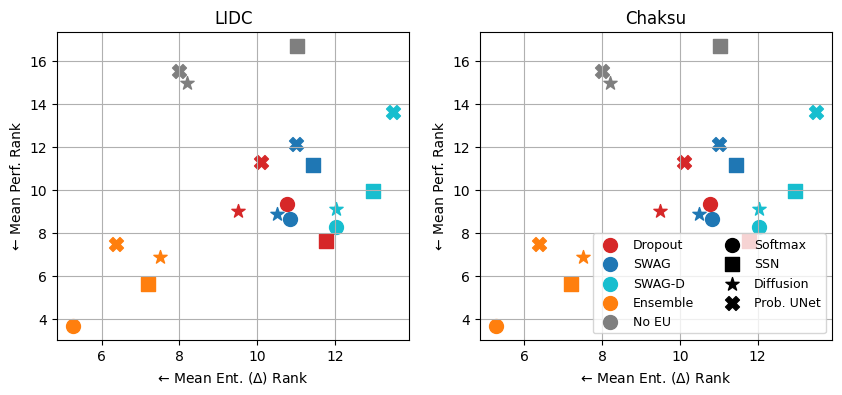

In [122]:
from helpers import load_result_table,model_scatter
import matplotlib.pyplot as plt
table = load_result_table(formatter="{AU}_{EU}_{seed}",epochs=[1000,500],
                           loop_params = {
                            "AU": ["softmax", "ssn", "diffusion", "prob_unet2"],
                            "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/origlidc128/test_results/",
                aggregation_type = "border_normalized",#"border_normalized", "patch_level"
                add_avg_ood = True,
                ace_type="gace",
                add_rank=True,
                mean_seeded_table="01234")
# ged is small what good
kwargs = {"x": "ENTRANK_avg", "y": "PERFRANK_avg", "xlabel": "← Mean Ent. ($\Delta$) Rank", "ylabel": "← Mean Perf. Rank", 
         "equal_scaling": False, "plot_legend": False, "entangle_is_up": None,
         "add_xy": False, "title": "LIDC"}
fig, axs = plt.subplots(1,2, figsize=(10,4))

model_scatter(table=table, ax=axs[0],**kwargs);

table_chaksu = load_result_table(formatter="{AU}_{EU}_{seed}",epochs=[500],
                        loop_params = {
                        "AU": ["softmax", "ssn", "diffusion", "prob_unet"],
                        "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
            },
            save_path = "/home/jloch/Desktop/diff/luzern/values/saves/chaksu128/test_results/",
            aggregation_type = "border_normalized",#"border_normalized", "patch_level"
            add_avg_ood = True,
            add_rank=True,
            ace_type="ace",
            mean_seeded_table="01234")

# ged is small what good
kwargs = {"x": "ENTRANK_avg", "y": "PERFRANK_avg", "xlabel": "← Mean Ent. ($\Delta$) Rank", "ylabel": "← Mean Perf. Rank", 
         "equal_scaling": False, "plot_legend": True, "entangle_is_up": None,
         "add_xy": False, "title": "Chaksu"}
#fig, ax = plt.subplots(figsize=(15,10))
model_scatter(table=table, ax=axs[1], **kwargs);
#plt.tight_layout()
#
save_path = "/home/jloch/Desktop/diff/writing/ECCV2026/ECCV_2026_AU_EU/images2/scatter_rank.pdf"
#save_path = None
if save_path is not None:
    plt.savefig(save_path, bbox_inches="tight")

# GED vs AU scatter (Fig 15)

Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4
Skipping missing version: softmax_none_0


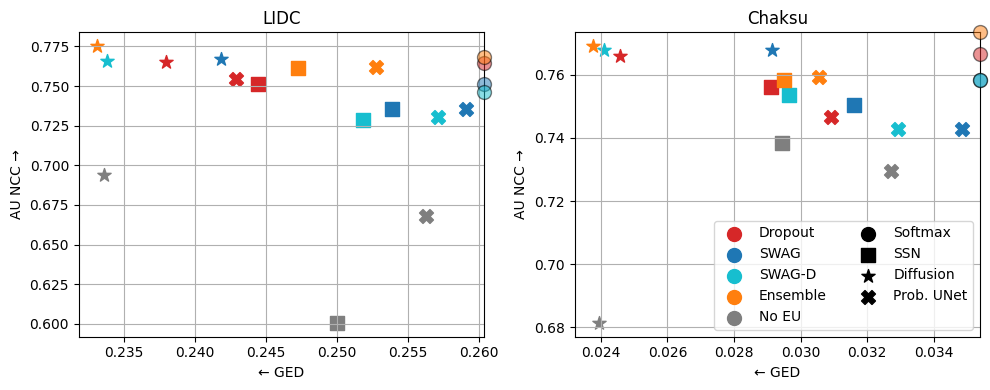

In [123]:
from helpers import model_scatter
from helpers import load_result_table
import matplotlib.pyplot as plt

table_chaksu = load_result_table(formatter="{AU}_{EU}_{seed}",
                          epochs=[500],
                           loop_params = {
                            "AU": ["softmax", "ssn", "diffusion", "prob_unet"],
                            "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/chaksu128/test_results/",
                aggregation_type = "border_normalized",#"border_normalized", "patch_level"
                mean_seeded_table = "01234",
                add_avg_ood = True,
                add_rank=True)
table_lidc = load_result_table(formatter="{AU}_{EU}_0",
                          epochs=[500,1000],
                           loop_params = {
                            "AU": ["softmax", "ssn", "diffusion", "prob_unet2"],
                            "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/origlidc128/test_results/",
                aggregation_type = "border_normalized",#"border_normalized", "patch_level"
                add_avg_ood = True,
                add_rank=True)
kwargs = {"y": "AU_ncc[id]", "x": "id_ged", "ylabel": "AU NCC →", "xlabel": "← GED",
         "equal_scaling": False, "plot_legend": True, "entangle_is_up": None,
         "mini_mean": False, "mini_size_multiplier": 0.4, "mini_alpha": 0.4, "add_xy": False,
         "ignore_for_axis": { "AU": ["softmax"], "EU": []}, }
fig, axs = plt.subplots(1,2, figsize=(10,4))
model_scatter(table=table_chaksu, ax=axs[1], title="Chaksu", **kwargs);
#change legend to 2 cols
# set pos to center left:
kwargs["plot_legend"] = False
model_scatter(table=table_lidc, ax=axs[0], title="LIDC", **kwargs);
plt.tight_layout()
axs[1].legend(ncol=2)
save_path = "/home/jloch/Desktop/diff/writing/ECCV2026/ECCV_2026_AU_EU/images2/scatter_ged_ncc.pdf"
#save_path = None
if save_path is not None:
    plt.savefig(save_path, bbox_inches="tight")

# ACE vs ECE

Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4
Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4
Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4
Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4
Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing

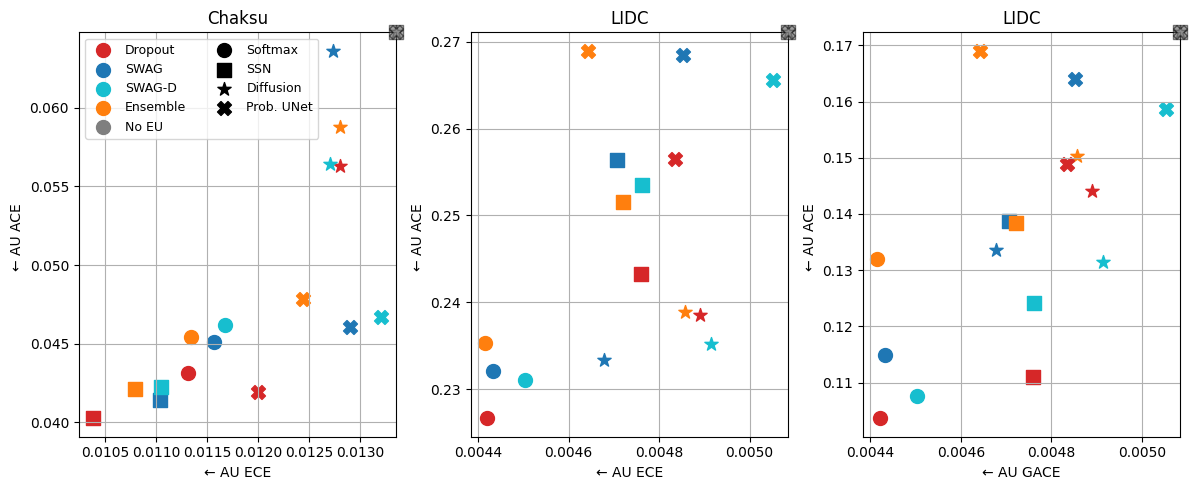

In [124]:
from helpers import model_scatter
from helpers import load_result_table
import matplotlib.pyplot as plt

table_chaksu = load_result_table(formatter="{AU}_{EU}_{seed}",epochs=[500],
                        loop_params = {
                        "AU": ["softmax", "ssn", "diffusion", "prob_unet"],
                        "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
            },
            save_path = "/home/jloch/Desktop/diff/luzern/values/saves/chaksu128/test_results/",
            aggregation_type = "border_normalized",#"border_normalized", "patch_level"
            add_avg_ood = True,
            add_rank=True,
            ace_type="ace",
            mean_seeded_table="01234")

table_chaksu_ece = load_result_table(formatter="{AU}_{EU}_{seed}",epochs=[500],
                        loop_params = {
                        "AU": ["softmax", "ssn", "diffusion", "prob_unet"],
                        "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
            },
            save_path = "/home/jloch/Desktop/diff/luzern/values/saves/chaksu128/test_results/",
            aggregation_type = "border_normalized",#"border_normalized", "patch_level"
            add_avg_ood = True,
            add_rank=True,
            ace_type="ece",
            mean_seeded_table="01234")

table_lidc = load_result_table(formatter="{AU}_{EU}_{seed}",
                          epochs=[500,1000],
                           loop_params = {
                            "AU": ["softmax", "ssn", "diffusion", "prob_unet2"],
                            "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/origlidc128/test_results/",
                aggregation_type = "border_normalized",#"border_normalized", "patch_level"
                add_avg_ood = True,
                add_rank=True,
                ace_type="ace",
                mean_seeded_table="01234")

table_lidc_gace = load_result_table(formatter="{AU}_{EU}_{seed}",
                          epochs=[500,1000],
                           loop_params = {
                            "AU": ["softmax", "ssn", "diffusion", "prob_unet2"],
                            "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/origlidc128/test_results/",
                aggregation_type = "border_normalized",#"border_normalized", "patch_level"
                add_avg_ood = True,
                add_rank=True,
                ace_type="gace",
                mean_seeded_table="01234")
table_lidc_ece = load_result_table(formatter="{AU}_{EU}_{seed}",
                          epochs=[500,1000],
                           loop_params = {
                            "AU": ["softmax", "ssn", "diffusion", "prob_unet2"],
                            "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/origlidc128/test_results/",
                aggregation_type = "border_normalized",#"border_normalized", "patch_level"
                add_avg_ood = True,
                add_rank=True,
                ace_type="ece",
                mean_seeded_table="01234")

table_chaksu["AU_ece"] = table_chaksu_ece["AU_ace"]
table_lidc["AU_ece"] = table_lidc_ece["AU_ace"]
table_lidc["AU_gace"] = table_lidc_gace["AU_ace"]

kwargs = {"y": "AU_ace[id]", "x": "AU_ece[id]", "ylabel": "← AU ACE ", "xlabel": "← AU ECE",
         "equal_scaling": False, "plot_legend": True, "entangle_is_up": None,
         "mini_mean": False, "mini_size_multiplier": 0.4, "mini_alpha": 0.4, "add_xy": False, "title": "Chaksu",
         "ignore_for_axis": { "EU": ["none"]}, }
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12,5))
model_scatter(table=table_chaksu, ax=axs[0], **kwargs);
model_scatter(table=table_lidc, ax=axs[1], **{**kwargs, "title": "LIDC", "plot_legend": 0});
model_scatter(table=table_lidc, ax=axs[2], **{**kwargs, "y": "AU_gace[id]", "xlabel": "← AU GACE", "title": "LIDC","plot_legend": 0});
plt.tight_layout()
save_path = "/home/jloch/Desktop/diff/writing/ECCV2026/ECCV_2026_AU_EU/images2/scatter_ece_ace.pdf"
#save_path = None
if save_path is not None:
    plt.savefig(save_path, bbox_inches="tight")

# n_pred sweep

0.5634898596885096 0.5954688415219636
0.5997734943835129 0.7770607155946895
0.226697231945944 0.26136253386627084
0.44723526780722356 0.6770658615677065
0.642082670026613 0.7806833236550604
0.03679526474368397 0.056465181450324614


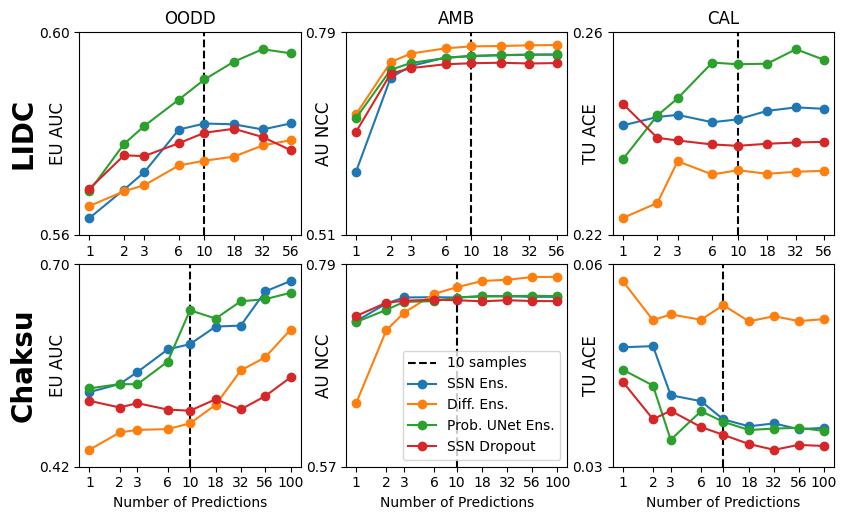

In [126]:
import numpy as np
from helpers import model_scatter
from helpers import load_result_table
import matplotlib.pyplot as plt
import pandas as pd


names = ["ssn_ensemble", "diffusion_ensemble", "prob_unet_ensemble", "ssn_dropout"]
names2 = ["ssn_ensemble", "diffusion_ensemble", "prob_unet2_ensemble", "ssn_dropout"]
names_pretty = ["SSN Ens.", "Diff. Ens.", "Prob. UNet Ens.", "SSN Dropout"]
skip_load = False
if skip_load:
    print("Skipping loading tables")
else:
    table_chaksu = load_result_table(formatter="{name}_0_n{n_pred}",epochs=[500],
                            loop_params = {
                            "AU": ["ssn"],
                            "EU": ["dropout"],
                            "name": names,
                            "n_pred": [ "1", "2", "3", "6", "18", "32", "56", "100"],
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/chaksu128/test_results/",
                aggregation_type = "border_normalized",#"border_normalized", "patch_level"
                add_avg_ood = True,
                add_rank=True,
                ace_type="ace")
    table_chaksu10 = load_result_table(formatter="{name}_0",epochs=[500],
                            loop_params = {
                            "AU": ["ssn"],
                            "EU": ["dropout"],
                            "name": names,
                            "n_pred": [ "10"],
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/chaksu128/test_results/",
                aggregation_type = "border_normalized",#"border_normalized", "patch_level"
                add_avg_ood = True,
                add_rank=True,
                ace_type="ace")
    table_lidc = load_result_table(formatter="{name}_0_n{n_pred}",epochs=[500,1000],
                            loop_params = {
                            "AU": ["ssn"],
                            "EU": ["dropout"],
                            "name": names2,
                            "n_pred": [ "1", "2", "3", "6", "18", "32", "56"],
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/origlidc128/test_results/",
                aggregation_type = "border_normalized",#"border_normalized", "patch_level"
                add_avg_ood = True,
                add_rank=True,
                ace_type="ace")
    table_lidc10 = load_result_table(formatter="{name}_0",epochs=[500,1000],
                            loop_params = {
                            "AU": ["ssn"],
                            "EU": ["dropout"],
                            "name": names2,
                            "n_pred": [ "10"],
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/origlidc128/test_results/",
                aggregation_type = "border_normalized",#"border_normalized", "patch_level"
                add_avg_ood = True,
                add_rank=True,
                ace_type="ace")

    #concat tables
    table_chaksu = pd.concat([table_chaksu, table_chaksu10], ignore_index=True)
    table_lidc = pd.concat([table_lidc, table_lidc10], ignore_index=True)
fig, axs = plt.subplots(2,3, figsize=(8,5))
# line plots of EU_auc[ood],AU_ncc[id],TU_ace[id], vs n_pred

for j in range(2):
    if j==0:
        vers = table_lidc["version"]
        n_pred = table_lidc["n_pred"]
        auc = [item["ood"] for item in table_lidc["EU_auc"]]
        ncc = [item["id"] for item in table_lidc["AU_ncc"]]
        ace = [item["id"] for item in table_lidc["TU_ace"]]
    else:
        vers = table_chaksu["version"]
        n_pred = table_chaksu["n_pred"]
        auc = [item["ood"] for item in table_chaksu["EU_auc"]]
        ncc = [item["id"] for item in table_chaksu["AU_ncc"]]
        ace = [item["id"] for item in table_chaksu["TU_ace"]]
    for i, m, metric, task in zip(range(3), [auc,ncc,ace], ["EU AUC", "AU NCC", "TU ACE"], ["OODD", "AMB", "CAL"]):

        axs[j,i].axvline(x=10, color="k", linestyle="--", label="10 samples")
        y_min, y_max = np.inf, -np.inf
        names3 = names2 if j==0 else names
        for name,name_pretty in zip(names3, names_pretty):
            idx = [item.startswith(name) for item in vers]
            # sort by n_pred
            x = n_pred[idx].astype(int).values
            y = np.array(m)[idx]
            sorted_idx = np.argsort(x)
            x = x[sorted_idx]
            y = y[sorted_idx]
            axs[j,i].plot(x, y, marker="o", label=name_pretty)
            y_min, y_max = np.min(y, initial=y_min), np.max(y, initial=y_max)
        print(y_min, y_max)
        axs[j,i].set_xscale("log")
        #replace xticks with the used values
        axs[j,i].set_xticks(n_pred.astype(int).unique(), labels=n_pred.astype(int).unique())
        #remove the minor ticks
        axs[j,i].minorticks_off()
        if j==1:
            axs[j,i].set_xlabel("Number of Predictions")
        if j==0:
            axs[j,i].set_title(task)
        axs[j,i].set_ylabel(metric, labelpad=-20, fontsize=12)
        # set yticks as min and max (+-5%)
        if i==1:
            y_min, y_max = y_min - 0.5*(y_max-y_min), y_max + 0.1*(y_max-y_min)
        else:
            y_min, y_max = y_min - 0.1*(y_max-y_min), y_max + 0.1*(y_max-y_min)
        axs[j,i].set_yticks([y_min, y_max], labels=[f"{y_min:.2f}", f"{y_max:.2f}"])
#no side padding
plt.tight_layout(pad=0)
axs[1,1].legend()
axs[0,0].text(-0.25, 0.5, "LIDC", transform=axs[0,0].transAxes, fontsize=20, 
              fontweight="bold", va="center", ha="center", rotation=90)
axs[1,0].text(-0.25, 0.5, "Chaksu", transform=axs[1,0].transAxes, fontsize=20, 
              fontweight="bold", va="center", ha="center", rotation=90)

save_path = "/home/jloch/Desktop/diff/writing/ECCV2026/ECCV_2026_AU_EU/images2/n_pred_plot.pdf"
#save_path = None
if save_path is not None:
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0)

# random stuff

Skipping missing version: softmax_none_0
Skipping missing version: softmax_none_1
Skipping missing version: softmax_none_2
Skipping missing version: softmax_none_3
Skipping missing version: softmax_none_4


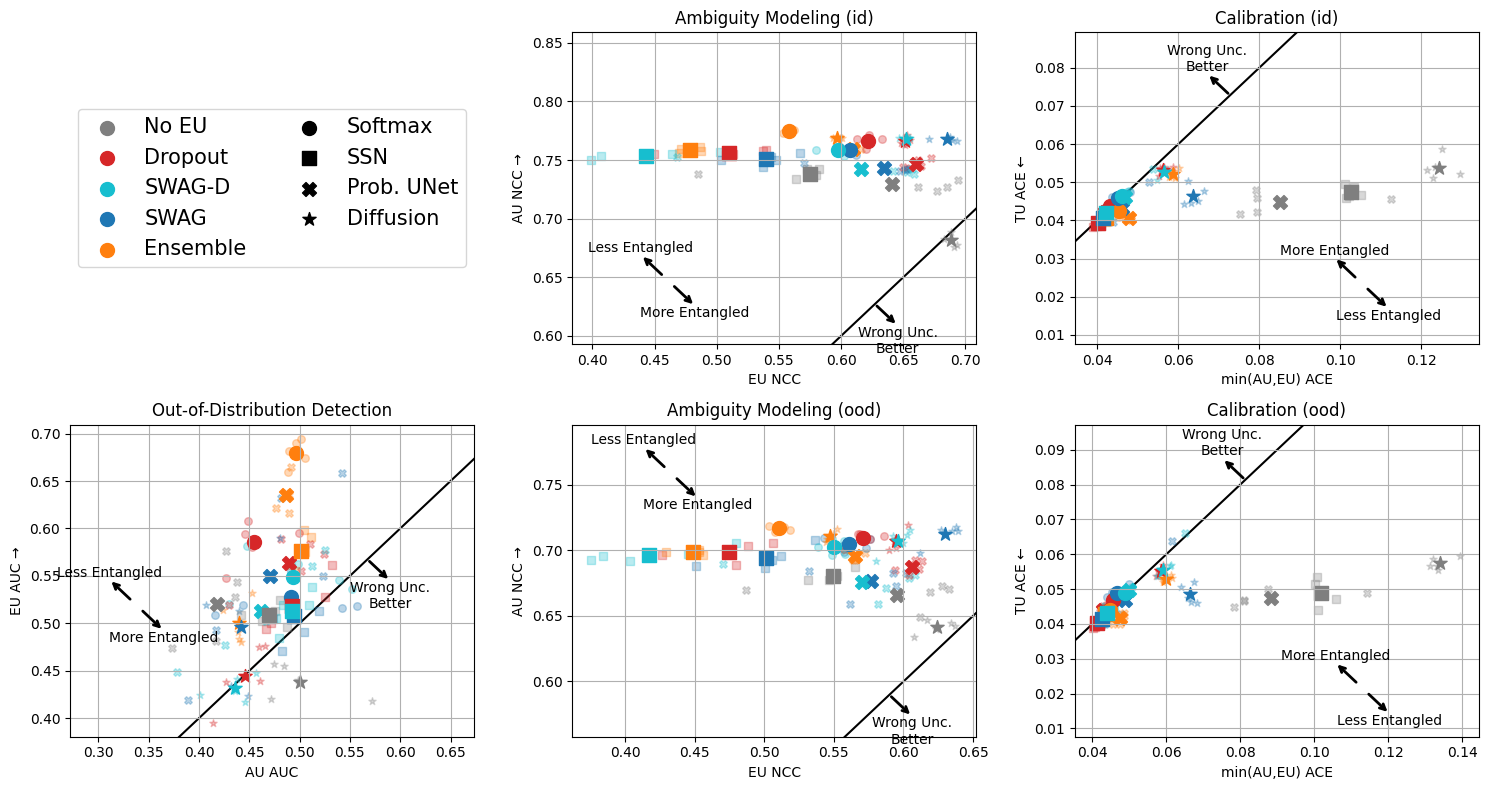

In [ ]:
from helpers import model_scatter, plot_scatter_grid
# chaksu
from helpers import load_result_table, plot_metric_matrix, plot_mm_grid
mini_tables = []
for seed in "01234":
    table = load_result_table(formatter="{AU}_{EU}_"+seed,
                          epochs=[500],
                           loop_params = {
                            "AU": ["softmax", "ssn", "diffusion", "prob_unet"],
                            "EU": ["swag", "dropout", "swag_diag", "none", "ensemble"]
                },
                save_path = "/home/jloch/Desktop/diff/luzern/values/saves/chaksu128/test_results/",
                aggregation_type = "border_normalized",#"border_normalized", "patch_level"
                ace_type="ace",
                add_avg_ood = True,
                add_rank=True)
    mini_tables.append(table)
plot_scatter_grid(table=None, mini_tables=mini_tables, override={"mini_alpha": 0.3},);#,
                 # save_path="/home/jloch/Desktop/diff/writing/ECCV2026/ECCV_2026_AU_EU/images/scatter_grid_chaksu.pdf");

In [1]:
import torch
loaded = torch.load("/home/jloch/Desktop/diff/luzern/values/saves/single_rater_chaksu/softmax_dropout_0/scheduled_ckpts/exp-epoch=0010.ckpt", weights_only=False)

In [2]:
loaded.keys()

dict_keys(['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'hparams_name', 'hyper_parameters', 'ema_state_dict'])

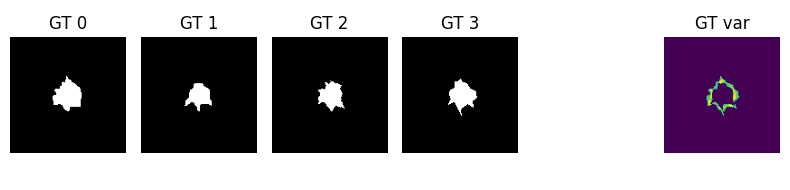

In [103]:
import numpy as np
import matplotlib.pyplot as plt

p = "/home/jloch/Desktop/diff/luzern/values_datasets/origlidc128/preprocessed/labels/0001_000_00_mask.npy"
gts = []
for i in "0123":
    gts.append(np.load(p.replace("00_mask", f"0{i}_mask")))

# figure with each ground truth individually, then mean and std aggregated across the 4 raters
fig, axs = plt.subplots(1,6, figsize=(8,2))
for i in range(4):
    axs[i].imshow(gts[i], cmap="gray")
    axs[i].set_title(f"GT {i}")
mean_gt = np.mean(gts, axis=0)
var_gt = np.var(gts, axis=0)
#axs[4].imshow(mean_gt, cmap="inferno")
#axs[4].set_title("Mean GT")
axs[5].imshow(var_gt, cmap="viridis")
axs[5].set_title("GT var")
for ax in axs:
    ax.axis("off")
plt.tight_layout()

Text(0.5, 1.0, 'AUROC')

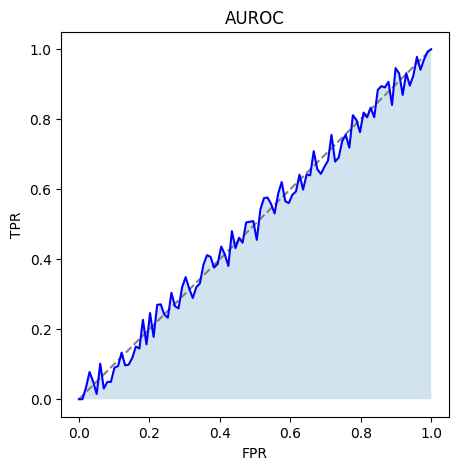

In [17]:
# AUROC vis
# simple visualization of X-axis arrow and Y-axis arrow with TPR and FPR labels.
# a blue curve with shaded light-blue area is shown with the text "AUROC", around 0.85 value with 
# some zig-sagging curve that is simulated with random noise but generally increasing from (0,0) to (1,1).
fig, ax = plt.subplots(figsize=(5,5))
ax.plot([0,1], [0,1], color="gray", linestyle="--", label="Random")
x = np.linspace(0,1,100)
y = x + 0.1*np.random.rand(100) - 0.05
y = np.clip(y, 0, 1)
ax.plot(x, y, color="blue")
ax.fill_between(x, y, alpha=0.2)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("AUROC")

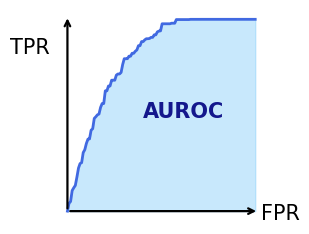

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducible randomness
np.random.seed(4)

# Small compact figure
fig, ax = plt.subplots(figsize=(3, 2.2))

# ROC-like curve
x = np.linspace(0, 1, 120)

# Good classifier shape
y = 1 - (1 - x) ** 4

# Add slight zig-zag noise
noise = np.random.normal(scale=0.015, size=len(x))
y = np.clip(y + noise, 0, 1)

# Keep monotonic-ish increasing behavior
y = np.maximum.accumulate(y)
y[0] = 0
y[-1] = 1

# Shaded AUROC area
ax.fill_between(x, y, 0, color="lightskyblue", alpha=0.45)

# ROC curve
ax.plot(x, y, color="royalblue", linewidth=2)

# Axis arrows
ax.annotate(
    "",
    xy=(1.02, 0),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle="->", lw=1.6, color="black"),
)

ax.annotate(
    "",
    xy=(0, 1.02),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle="->", lw=1.6, color="black"),
)

# Labels
ax.text(1.03, -0.015, "FPR", ha="left", va="center", fontsize=15)
ax.text(-0.2, 0.8, "TPR", ha="center", va="bottom", fontsize=15)

# AUROC annotation
ax.text(0.62, 0.52, "AUROC", fontsize=15, color="navy", alpha=0.9, ha="center", va="center", fontweight="bold")

# Remove all axes/ticks
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

# Limits
ax.set_xlim(-0.02, 1.05)
ax.set_ylim(-0.02, 1.05)

plt.tight_layout(pad=0.2)
plt.show()

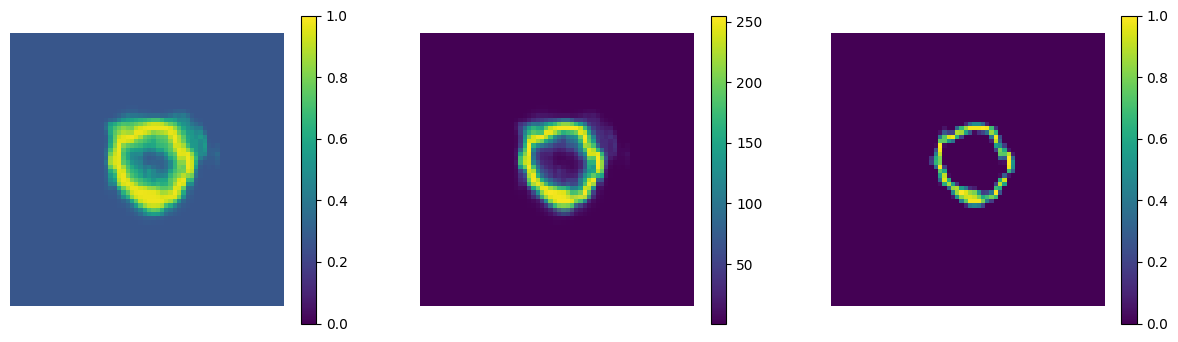

In [95]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
p = "/home/jloch/Pictures/Screenshots/Screenshot from 2026-05-26 14-17-41.png"
im = np.array(Image.open(p))
# crop all white pixels (ish) pixels, then resize to 64x64
colsum = im[:,:,:3].mean(axis=(0,2))
rowsum = im[:,:,:3].mean(axis=(1,2))
col_mask = colsum < 255*0.5
row_mask = rowsum < 255*0.5
im_cropped = im[row_mask][:,col_mask]
#resize with NN interp
im_cropped = Image.fromarray(im_cropped).resize((64,64), resample=Image.NEAREST)
#map pixels to intensities using viridis cmap -> [0,1] range
im_cropped = np.array(im_cropped)
im_cropped2 = im_cropped[:,:,:3].mean(axis=2) / 255
im_cropped3 = 1/(1+np.exp(a*im_cropped2+b))
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
a = -10
b = 3
plt.imshow(im_cropped3, cmap="viridis",vmin=0,vmax=1)
plt.colorbar()
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(im_cropped)
plt.colorbar()
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(im_cropped2*4.5-2, cmap="viridis",vmin=0,vmax=1)
plt.colorbar()
plt.axis("off")
plt.show()


(-0.5, 127.5, 127.5, -0.5)

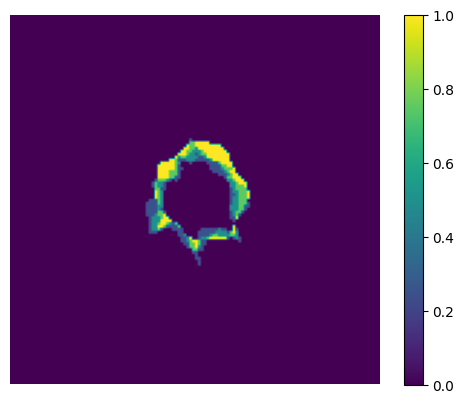

In [116]:
p = "/home/jloch/Pictures/Screenshots/Screenshot from 2026-05-26 14-45-50.png"
im = np.array(Image.open(p))
# crop all white pixels (ish) pixels, then resize to 64x64
colsum = im[:,:,:3].mean(axis=(0,2))
rowsum = im[:,:,:3].mean(axis=(1,2))
col_mask = colsum < 255*0.5
row_mask = rowsum < 255*0.5
im_cropped = im[row_mask][:,col_mask]
#resize with NN interp
im_cropped = Image.fromarray(im_cropped).resize((128,128), resample=Image.NEAREST)

#show error wrt the 4 gts in "gts" and plot error rate with viridis cmap
im_cropped = ((np.array(im_cropped)[:,:,0]/255)>0.5).astype(float)
errors = []
for gt in gts:
    error = np.abs(im_cropped - gt)
    errors.append(error)
mean_error = np.mean(errors, axis=0)
plt.imshow(mean_error, cmap="viridis")
plt.colorbar()
plt.axis("off")

In [111]:
gts[0].max()

1

In [104]:
gts[0].shape

(128, 128)

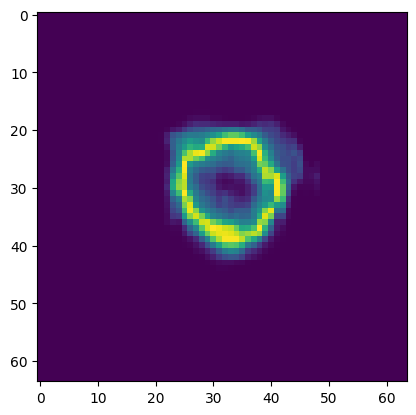

In [97]:
plt.imshow(prob)

(-0.5, 63.5, 63.5, -0.5)

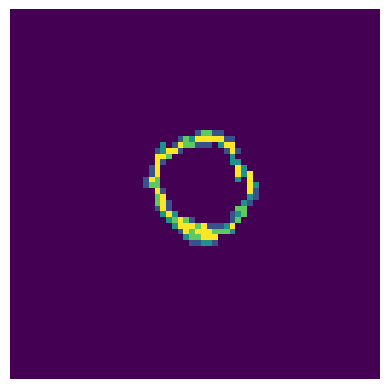

In [101]:
prob = im_cropped2*4.5-2
#sample 4 binary masks with this prob and add them together, then clip to [0,1]
masks = []
for i in range(4):
    mask = np.random.rand(*prob.shape) < prob
    masks.append(mask.astype(float))
masks_sum = np.clip(np.mean(masks, axis=0), 0, 1)
plt.imshow(masks_sum, cmap="viridis", vmin=0, vmax=1)
plt.axis("off")

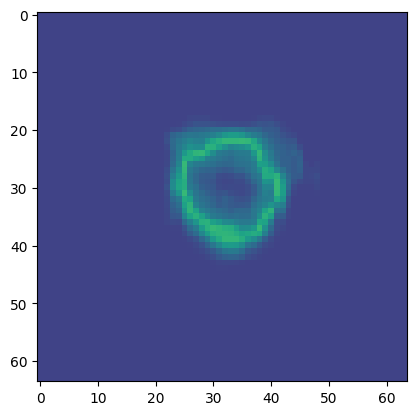

In [91]:
plt.imshow(im_cropped2, cmap="viridis",vmin=0,vmax=1)

In [90]:
im_cropped2.min()

0.2

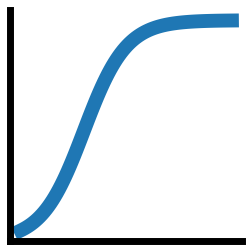

In [76]:
plt.figure(figsize=(3,3))
x = np.linspace(0,1,100)
a = -10
b = 3
y = 1/(1+np.exp(a*x+b))
plt.xticks([])
plt.yticks([])
plt.plot(x,y, linewidth=10)
#sit plot border width
plt.gca().spines['top'].set_linewidth(0)
plt.gca().spines['right'].set_linewidth(0)
plt.gca().spines['bottom'].set_linewidth(5)
plt.gca().spines['left'].set_linewidth(5)

In [41]:
row_mask.shape

(3,)

In [40]:
im[row_mask].shape

IndexError: boolean index did not match indexed array along dimension 0; dimension is 760 but corresponding boolean dimension is 3

In [36]:
im.shape

(760, 775, 4)

In [37]:
col_mask.shape

(775,)

In [30]:
col_mask.shape

(775, 4)